# Analisis Exploratorio de Datos


## Diccionario de datos

El dataset tiene **7,043 clientes** (una fila por cliente) y **21 columnas**.

### Datos del cliente
| Columna | Qué significa | Valores |
|---|---|---|
| customerID | Código que identifica al cliente | Código único |
| gender | Género del cliente | Male / Female |
| SeniorCitizen | Si es adulto mayor | 1 = sí, 0 = no |
| Partner | Si tiene pareja | Yes / No |
| Dependents | Si tiene personas a su cargo | Yes / No |

### Servicios contratados
| Columna | Qué significa | Valores |
|---|---|---|
| PhoneService | Si tiene servicio de teléfono | Yes / No |
| MultipleLines | Si tiene varias líneas telefónicas | Yes / No / No phone service |
| InternetService | Tipo de internet | DSL / Fiber optic / No |
| OnlineSecurity | Servicio de seguridad en línea | Yes / No / No internet service |
| OnlineBackup | Servicio de respaldo en línea | Yes / No / No internet service |
| DeviceProtection | Protección del equipo | Yes / No / No internet service |
| TechSupport | Soporte técnico | Yes / No / No internet service |
| StreamingTV | Televisión por internet | Yes / No / No internet service |
| StreamingMovies | Películas por internet | Yes / No / No internet service |

### Información de la cuenta
| Columna | Qué significa | Valores |
|---|---|---|
| tenure | Meses que lleva el cliente con la empresa | Número (0 a 72) |
| Contract | Tipo de contrato | Month-to-month / One year / Two year |
| PaperlessBilling | Si recibe la factura digital | Yes / No |
| PaymentMethod | Cómo paga | Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic) |
| MonthlyCharges | Cuánto paga cada mes | Número |
| TotalCharges | Cuánto ha pagado en total | Número |

### Variable a predecir
| Columna | Qué significa | Valores |
|---|---|---|
| Churn | Si el cliente abandonó la empresa | Yes = se fue, No = sigue |

### Nota sobre "No internet service" y "No phone service"
- Seis columnas de servicios extra (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, `StreamingMovies`) tienen el valor **"No internet service"**.
  Significa que el cliente no tiene internet, por eso no puede tener esos servicios.
- `MultipleLines` tiene el valor **"No phone service"**, para los clientes sin teléfono.
- Esa información ya está en `InternetService` y `PhoneService`, así que en el
  preprocesamiento estos valores se reemplazan por **"No"**.


Para empezar cargamos los datos


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Vista general de los datos


In [26]:
df.info()
print("Nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Aquí vamos a tratar TotalCharges, que significa lo que ha pagado cada cliente. Lo que pasa es que al ejecutar el código anterior se ve que lo interpreta como texto y no como número. Esto pasa porque unos clientes tienen un espacio en blanco en lugar de un valor, así que para poder avanzar sin ese problema cambiamos el espacio en blanco por un valor nulo y luego convertimos la columna a número.

In [27]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)  # El espacio en blanco pasa a ser un valor nulo #
df["TotalCharges"] = df["TotalCharges"].apply(pd.to_numeric)  # Convertimos la columna a formato número #
print("Vacíos:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["tenure", "TotalCharges"]]

Vacíos: 11


,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


Los 11 clientes con el valor vacío tienen tenure = 0. Tenure es la antigüedad, así que son clientes que se acaban de registrar y todavía no han tenido su primera factura. Como solo son 11 filas de 7.043 (el 0,16%), eliminamos esos registros.

In [28]:
df.dropna(inplace=True)  # Eliminamos los registros que tienen algún valor nulo #
print(df.shape)
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)

(7032, 21)


Distribución de Churn (deserción)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


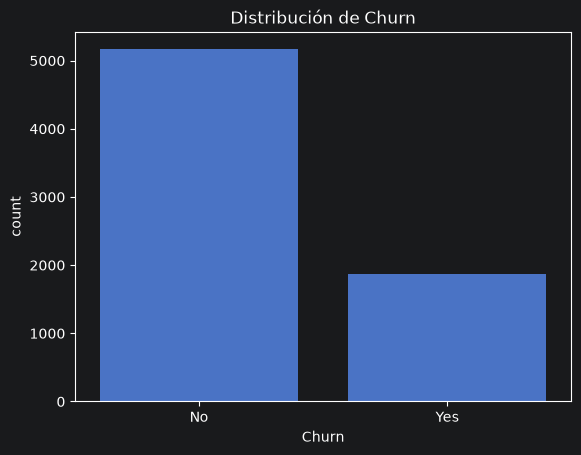

In [29]:
print(df["Churn"].value_counts(normalize=True) * 100)
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

Acá lo que nos muestra el gráfico es que la mayoría de los clientes sigue con la empresa (cerca del 73%) y que cerca del 27% desertó. Las dos clases no están equilibradas, y eso hay que tenerlo en cuenta al entrenar los modelos (`class_weight`).

Valores de las columnas de texto

In [30]:
for col in ["Contract", "PaymentMethod", "InternetService", "OnlineSecurity"]:
    print(col, df[col].unique())

Contract <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


Variables numéricas

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.650010       61.307408   2555.344141
Yes    17.979133       74.441332   1531.796094


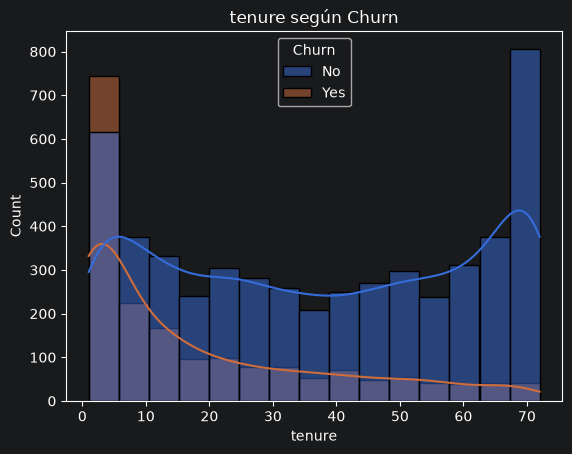

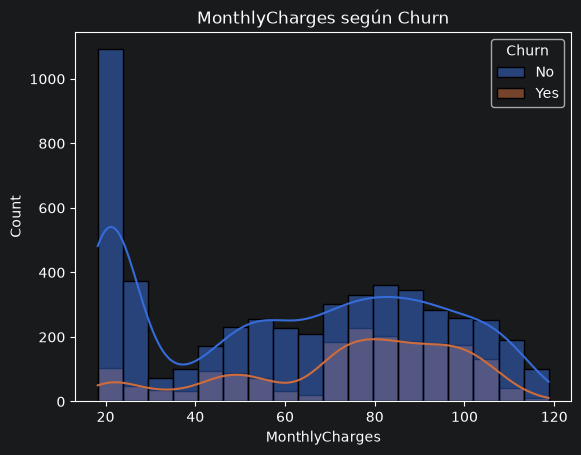

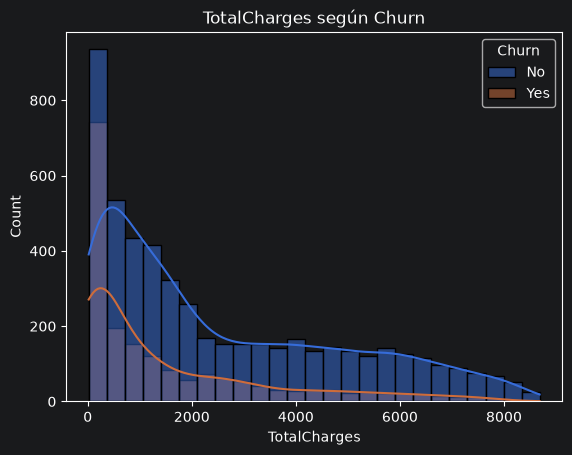

In [31]:
numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
print(df.groupby("Churn")[numericas].mean())

for col in numericas:
    sns.histplot(data=df, x=col, hue="Churn", kde=True)
    plt.title(col + " según Churn")
    plt.show()

Los clientes que se fueron llevaban menos tiempo con la empresa (unos 18 meses en promedio contra unos 38) y pagaban más al mes (unos \$74 contra unos \$61). En el histograma de tenure se ve que los que se fueron se concentran en los primeros meses. TotalCharges es menor en los que se fueron porque estuvieron menos tiempo pagando.

Boxplots

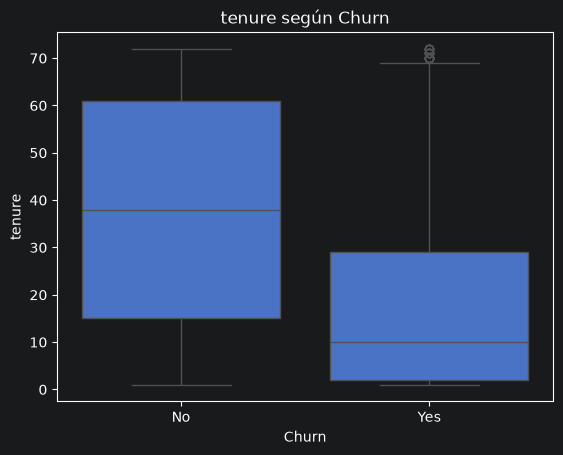

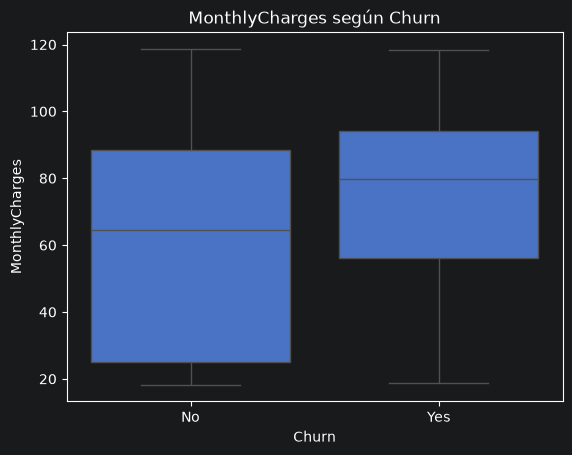

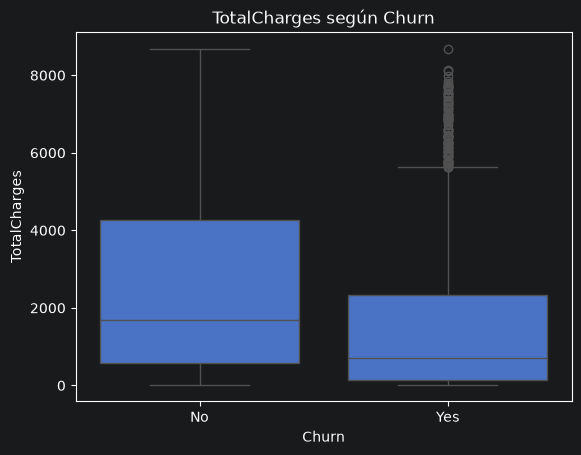

In [32]:
for col in numericas:
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(col + " según Churn")
    plt.show()

Los boxplots muestran lo mismo con las medianas: la mitad de los clientes que se fueron llevaba 10 meses o menos, mientras que la mediana de los que se quedaron es de 38 meses. En MonthlyCharges la mediana de los que se fueron es más alta.

Tasa de deserción por segmento

In [33]:
def tasa_churn(col):
    tasa = df.groupby(col)["Churn_num"].mean() * 100
    tasa.plot(kind="bar", color="steelblue")
    plt.title("Tasa de churn (%) por " + col)
    plt.ylabel("% churn")
    plt.xticks(rotation=20)
    plt.show()

Datos de cliente y cuenta

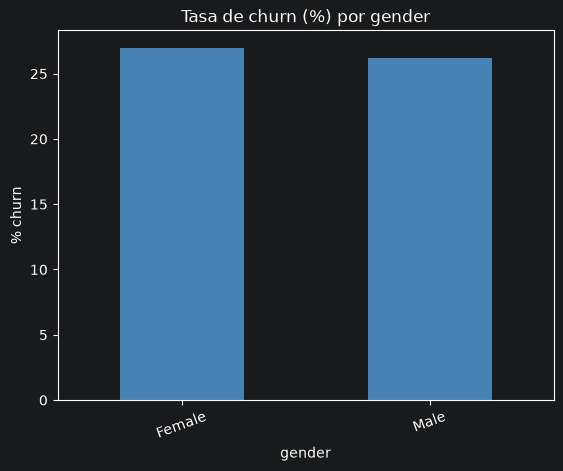

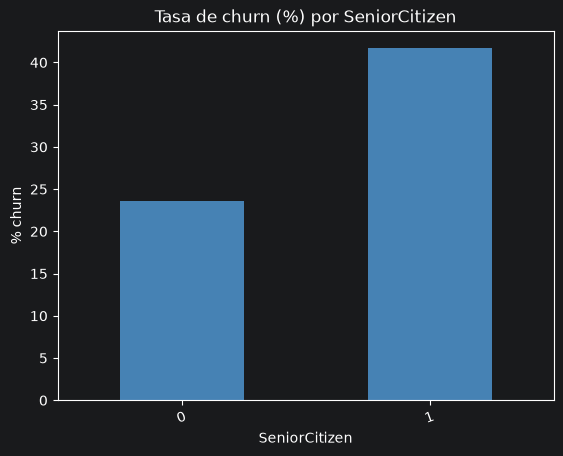

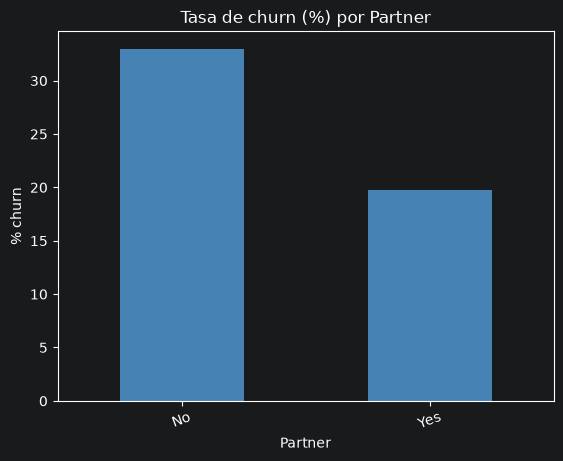

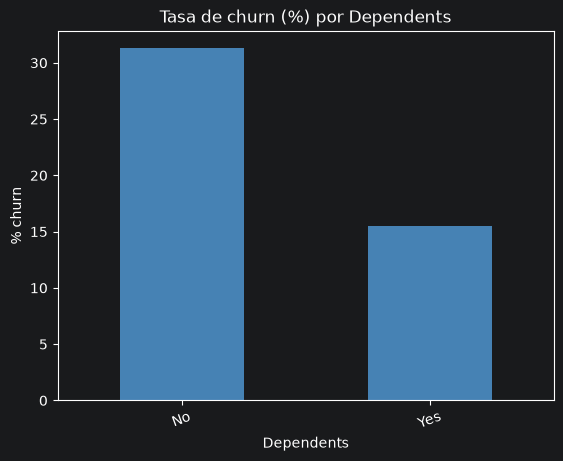

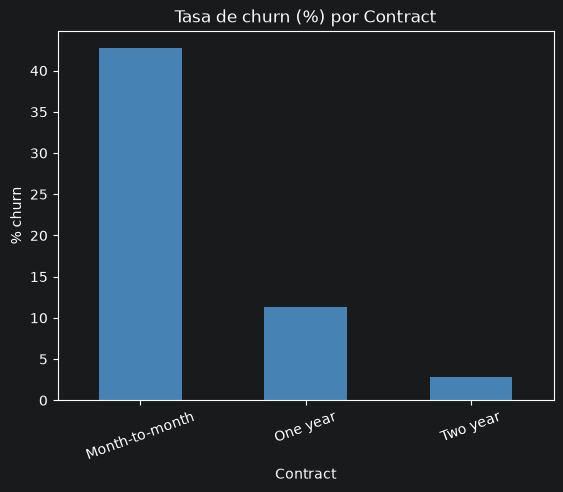

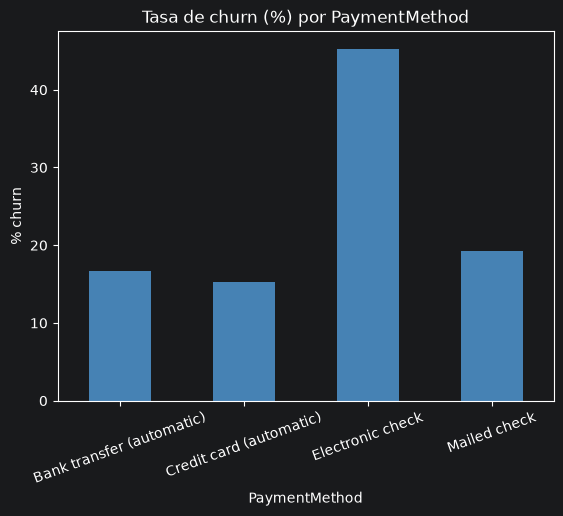

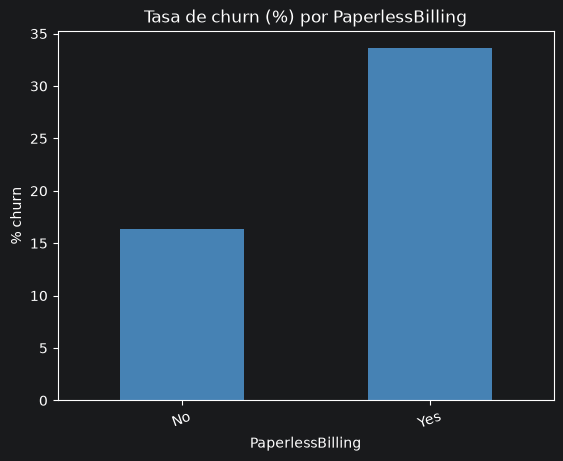

In [34]:
for col in ["gender", "SeniorCitizen", "Partner", "Dependents",
            "Contract", "PaymentMethod", "PaperlessBilling"]:
    tasa_churn(col)

El tipo de contrato es lo que más separa a los clientes: con contrato mensual se va cerca del 43%, con contrato de un año cerca del 11% y con contrato de dos años cerca del 3%. En el método de pago destaca el cheque electrónico (cerca del 45%); los otros tres están entre 15% y 19%. También se van más los adultos mayores (cerca del 42% contra 24%), los que no tienen pareja (33% contra 20%), los que no tienen dependientes (31% contra 16%) y los que reciben la factura digital (34% contra 16%). En gender las dos barras son casi iguales (27% y 26%).

Servicios contratados

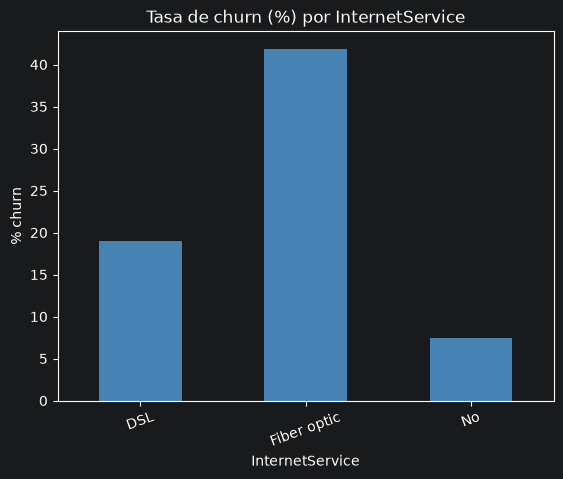

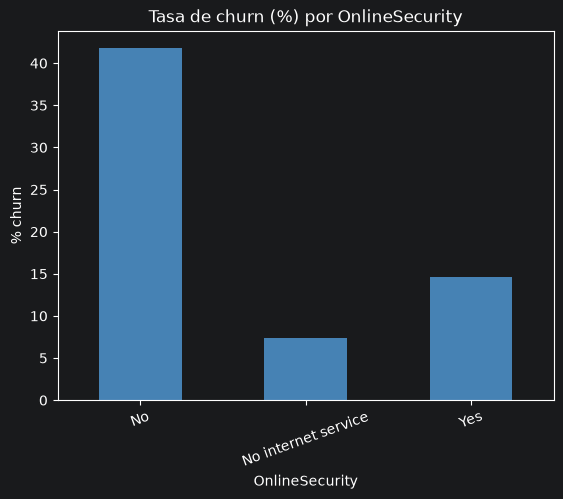

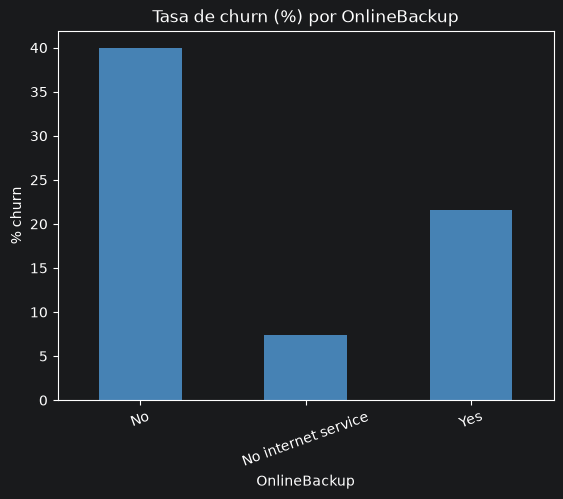

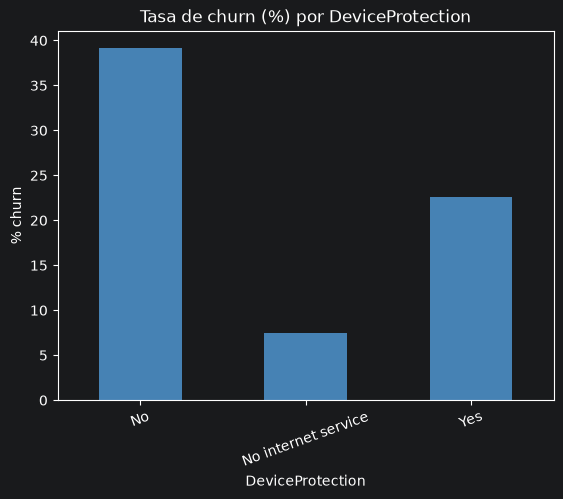

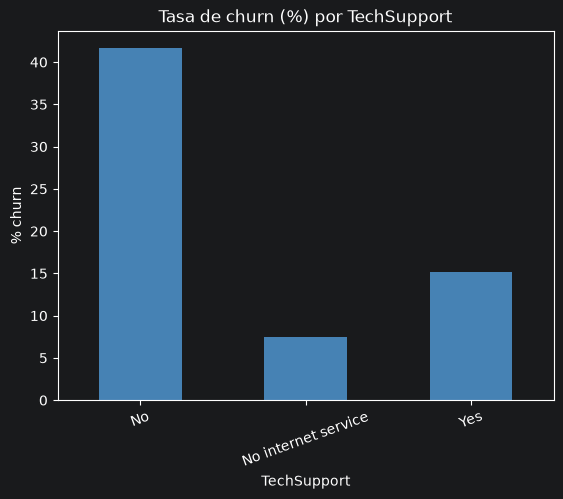

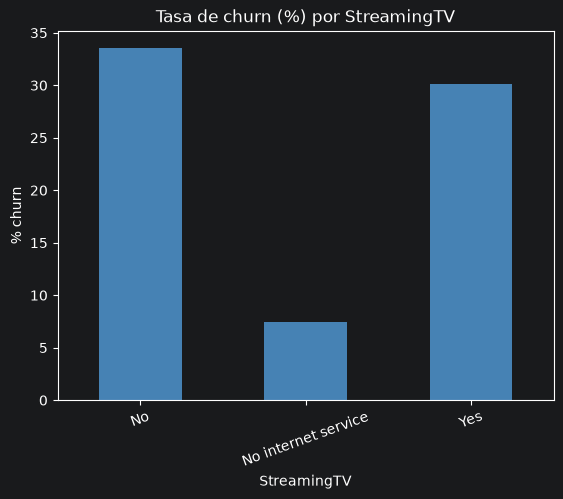

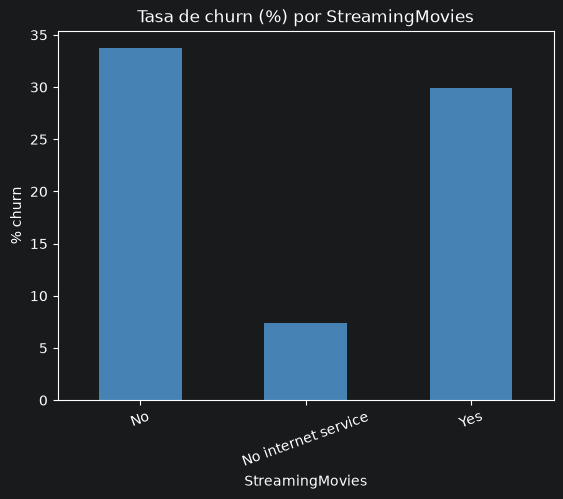

In [35]:
for col in ["InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]:
    tasa_churn(col)

Los clientes con internet de fibra óptica son los que más se van (cerca del 42%), contra 19% con DSL y 7% sin internet. Entre los que tienen internet, no tener seguridad en línea o soporte técnico sube la tasa a cerca del 42%, y tenerlos la baja a cerca del 15%. Con respaldo en línea y protección de equipo pasa lo mismo pero con menos diferencia (cerca de 40% contra 22%). En StreamingTV y StreamingMovies casi no hay diferencia (cerca de 34% contra 30%).

Cantidad de servicios adicionales: Como varios servicios adicionales bajan la tasa de churn, contamos cuántos tiene cada cliente (de 0 a 6) para ver si la cantidad también influye.

num_servicios
0    21.464076
1    45.755694
2    35.818006
3    27.394808
4    22.352941
5    12.478032
6     5.281690
Name: Churn_num, dtype: float64


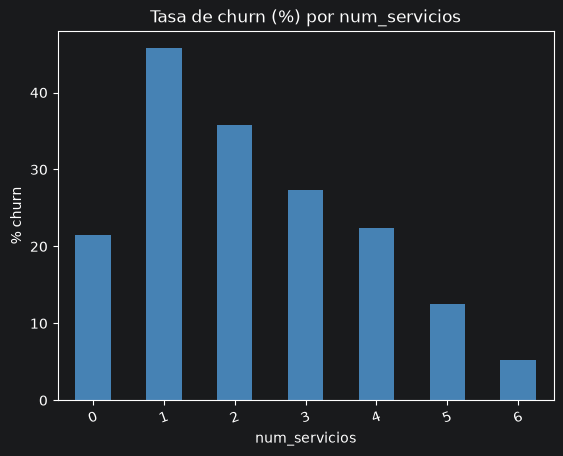

In [36]:
servicios = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
             "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_servicios"] = (df[servicios] == "Yes").sum(axis=1)

print(df.groupby("num_servicios")["Churn_num"].mean() * 100)
tasa_churn("num_servicios")

Con 1 servicio la tasa de churn es la más alta (cerca del 46%) y va bajando con cada servicio adicional hasta cerca del 5% con los 6. El grupo con 0 servicios tiene una tasa más baja (cerca del 21%) porque ahí están los 1.520 clientes sin internet, que casi no se van (7%). Por eso en el preprocesamiento se crea la variable `num_servicios`.

Antigüedad por grupo

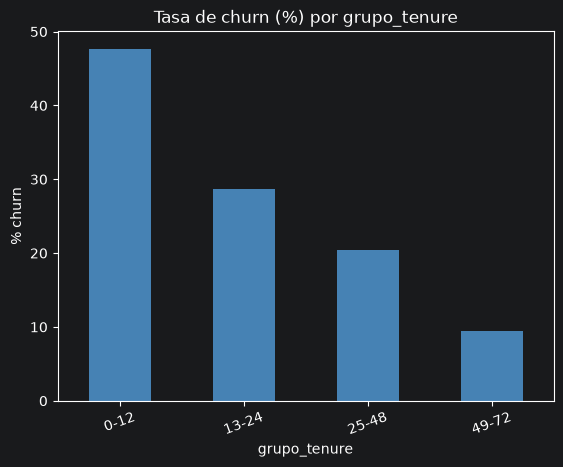

In [37]:
def grupo_antiguedad(tenure):
    if tenure <= 12:
        return "0-12"
    elif tenure <= 24:
        return "13-24"
    elif tenure <= 48:
        return "25-48"
    else:
        return "49-72"

df["grupo_tenure"] = df["tenure"].apply(grupo_antiguedad)
tasa_churn("grupo_tenure")

La tasa de churn baja conforme aumenta la antigüedad: cerca del 48% en el primer año, 29% en el segundo, 20% entre 25 y 48 meses y cerca del 10% después de 4 años. El primer año es el de mayor riesgo.

Correlaciones

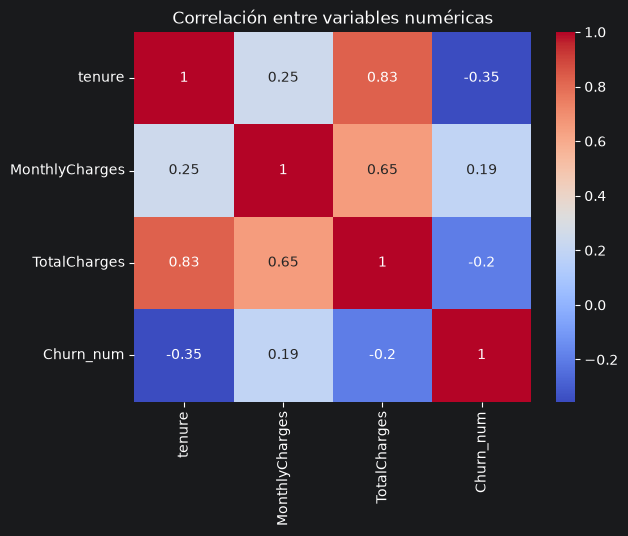

In [38]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

tenure tiene la correlación más fuerte con Churn (-0,35): a más antigüedad, menos abandono. MonthlyCharges tiene correlación positiva (0,19): los que pagan más al mes se van más. TotalCharges está muy relacionada con tenure (0,83), porque el total pagado depende del tiempo que lleva el cliente.

Aquí solo están las variables numéricas. La correlación de las demás variables con Churn se calcula en el notebook 02, después de convertirlas a número.

## Conclusiones del EDA

### Hallazgos principales
- **Limpieza:** se eliminaron 11 registros con `TotalCharges` vacío (clientes con tenure = 0). Quedan 7.032 clientes.
- **Desbalance:** cerca del 73% de los clientes se queda y cerca del 27% abandona.
  Al entrenar hay que usar `class_weight`.
- **Variables numéricas:** los clientes que se fueron llevaban en promedio unos 18 meses
  con la empresa, contra unos 38 de los que se quedaron, y pagaban más al mes
  (unos \$74 contra unos \$61).

### Tasa de churn por segmento (aproximada)
| Variable | Grupo de mayor riesgo | Grupo de menor riesgo |
|---|---|---|
| Contract | Mensual: ≈ 43% | Dos años: ≈ 3% |
| Antigüedad | 0 a 12 meses: ≈ 48% | 49 a 72 meses: ≈ 10% |
| PaymentMethod | Cheque electrónico: ≈ 45% | Tarjeta automática: ≈ 15% |
| InternetService | Fibra óptica: ≈ 42% | Sin internet: ≈ 7% |
| OnlineSecurity | Sin el servicio: ≈ 42% | Con el servicio: ≈ 15% |
| TechSupport | Sin el servicio: ≈ 42% | Con el servicio: ≈ 15% |
| SeniorCitizen | Adulto mayor: ≈ 42% | No adulto mayor: ≈ 24% |
| Partner | Sin pareja: ≈ 33% | Con pareja: ≈ 20% |
| Dependents | Sin dependientes: ≈ 31% | Con dependientes: ≈ 16% |
| PaperlessBilling | Factura digital: ≈ 34% | Factura en papel: ≈ 16% |
| Servicios adicionales | 1 servicio: ≈ 46% | 6 servicios: ≈ 5% |

### Variables que casi no influyen
- `gender`: las dos barras son casi iguales (≈ 27% contra ≈ 26%).
- `StreamingTV` y `StreamingMovies`: la diferencia entre tenerlos o no es de pocos puntos.

### Conclusión general
El cliente con mayor riesgo de abandonar es **nuevo, con contrato mensual, con fibra
óptica, paga con cheque electrónico y no tiene seguridad en línea ni soporte técnico**.
El cliente con menor riesgo es antiguo, con contrato de uno o dos años y con servicios
de seguridad y soporte.

### Recomendaciones para la empresa
- Ofrecer descuentos o beneficios para pasar a los clientes de contrato mensual a contratos
  de uno o dos años.
- Dar seguimiento especial durante el primer año, que es cuando más clientes se van.
- Promover los servicios de seguridad en línea y soporte técnico, porque los clientes que
  los tienen se quedan más.
- Revisar la calidad del servicio de fibra óptica y el proceso de pago con cheque electrónico.